<a href="https://colab.research.google.com/github/luisgonzalez4/FPDS/blob/main/Representacion_Digital_de_una_senal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importamos las librerias, en este caso usamos Numpy para generar arreglos y matplotlib para las graficas.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

Generamos el arreglo de $k$ donde $k\in \mathbb{Z}$.

En este caso graficaremos una función trigonometrica, dada por:
\begin{equation}
f(t)=sin(\omega t)u(t)
\end{equation}
donde $\omega=2\pi f$ y $f$ es la frecuencia de repetición, por ejemplo, si $f=1$ Hz, entonces el seno se repetira cada 1 seg. Por otro lado definimos el periodo de muestreo $T$, e.g. $T=0.1$ seg y obtenemos el tiempo discreto por $t=kT$


k, esta definido de 0 - 60


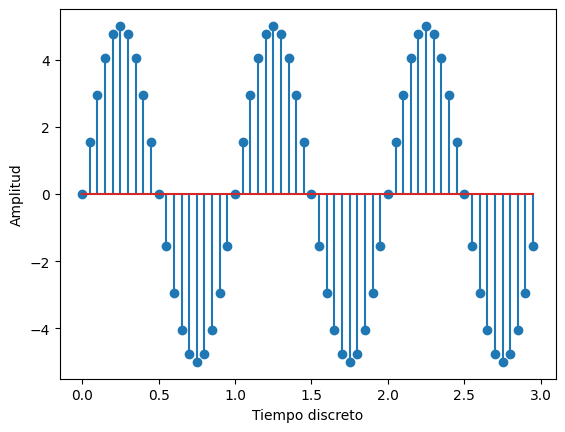

In [20]:
T=0.05 # periodo de muestreo
kT=np.arange(0,3,T) # ventana temporal para k=0,1,2,3....
f=1 # frecuencia de repetición: 1 seg
omega=2*np.pi*f # frecuencia angular
print('k, esta definido de 0 -',len(kT))
f=5*np.sin(omega*kT)
plt.stem(kT,f)
plt.xlabel('Tiempo discreto')
plt.ylabel('Amplitud')
#plt.ylim(-1,1)
plt.show()

Tomamos en cuenta la resolución del microcontrolador, por ejemplo $Q=0.3$

/tmp/ipykernel_1071/2832308132.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


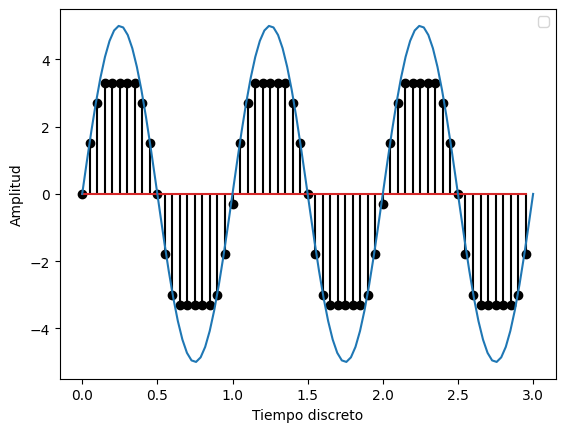

In [22]:
from matplotlib import legend
Q=0.3 # resolución de microcontrolador, en el arduino uno tenemos Q=4.88e-3
Vmax=3.3 # voltage maximo
Vmin=-3.3 # voltage minimo
fk=np.zeros_like(f)
t=np.linspace(0,3,100)
ft=5*np.sin(omega*t) # vector de tiempo continuo
for i in range(len(f)):
  fk[i]=Q*np.floor(f[i]/Q)
  if fk[i]>Vmax:
    fk[i]=Vmax
  elif fk[i]<Vmin:
    fk[i]=Vmin
plt.stem(kT,fk,'k') # señal discreta
plt.plot(t,ft) # señal continua
plt.xlabel('Tiempo discreto')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

